# EDA: Chunking Strategy Analysis

This notebook measures the actual character and word distributions of every knowledge-base  
source loaded by `src/document_loader.py`, then derives chunking parameters empirically.

The notebook is the **source of truth** for chunking decisions. `docs/eda_chunking_analysis.md`  
is updated from this analysis, not the other way around.

---
## Setup

In [ ]:
import sys
import os
from pathlib import Path
import re

# Set working directory to project root so relative paths in src/ resolve correctly
PROJECT_ROOT = Path("__file__").resolve().parent.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {Path.cwd()}")

Project root: /Users/jhonattan.reales/Library/Mobile Documents/com~apple~CloudDocs/MAESTRIA MIAA 2025-2026/Cursos semestres/SEMESTRE 3/IA_GENERATIVA/Talleres_proyecto/ecomarket-rag-assistant


In [2]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import defaultdict

from langchain_text_splitters import RecursiveCharacterTextSplitter

from src.document_loader import (
    load_returns_policy,
    load_shipping_policy,
    load_inventory,
    load_product_catalog,
    load_orders_as_docs,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 9

---
## 1. Load Documents

In [3]:
SOURCES = {
    "returns_policy": (load_returns_policy, "PDF"),
    "shipping_policy": (load_shipping_policy, "PDF"),
    "inventory": (load_inventory, "Excel"),
    "product_catalog": (load_product_catalog, "Excel"),
    "orders": (load_orders_as_docs, "JSON"),
}

raw_docs: dict[str, list] = {}
for name, (loader, _) in SOURCES.items():
    docs = loader()
    raw_docs[name] = docs
    print(f"{name:22s}  {len(docs):>4d} docs")

returns_policy             2 docs
shipping_policy            1 docs
inventory                200 docs
product_catalog          200 docs
orders                    30 docs


---
## 2. Dataset Overview

In [4]:
rows = []
for name, (_, dtype) in SOURCES.items():
    docs = raw_docs[name]
    lengths = [len(d.page_content) for d in docs]
    rows.append(
        {
            "Source": name,
            "Type": dtype,
            "Raw docs": len(docs),
            "Total chars": sum(lengths),
            "Avg chars/doc": round(sum(lengths) / len(lengths), 0) if lengths else 0,
        }
    )

overview = pd.DataFrame(rows)
totals = pd.DataFrame(
    [
        {
            "Source": "TOTAL",
            "Type": "",
            "Raw docs": overview["Raw docs"].sum(),
            "Total chars": overview["Total chars"].sum(),
            "Avg chars/doc": "",
        }
    ]
)
overview_all = pd.concat([overview, totals], ignore_index=True)
overview_all.style.set_caption("Dataset Overview")

,Source,Type,Raw docs,Total chars,Avg chars/doc
0,returns_policy,PDF,2,3327,1664.000000
1,shipping_policy,PDF,1,1627,1627.000000
2,inventory,Excel,200,50497,252.000000
3,product_catalog,Excel,200,53522,268.000000
4,orders,JSON,30,8418,281.000000
5,TOTAL,,433,117391,


---
## 3. Character Distribution per Source

In [5]:
stat_rows = []
for name in SOURCES:
    s = pd.Series([len(d.page_content) for d in raw_docs[name]])
    stat_rows.append(
        {
            "Source": name,
            "Count": int(s.count()),
            "Min": int(s.min()),
            "p25": int(s.quantile(0.25)),
            "Median": int(s.median()),
            "Mean": round(s.mean(), 1),
            "p75": int(s.quantile(0.75)),
            "Max": int(s.max()),
            "Std": round(s.std(), 1) if len(s) > 1 else 0.0,
        }
    )

stats = pd.DataFrame(stat_rows)
print(stats.to_string(index=False))

         Source  Count  Min  p25  Median   Mean  p75  Max   Std
 returns_policy      2 1420 1541    1663 1663.5 1785 1907 344.4
shipping_policy      1 1627 1627    1627 1627.0 1627 1627   0.0
      inventory    200  238  247     252  252.5  257  274   7.4
product_catalog    200  245  259     265  267.6  273  305  11.9
         orders     30  209  260     288  280.6  317  341  45.5


In [6]:
# Identify the structural boundary: largest structured document
structured = ["inventory", "product_catalog", "orders"]
max_structured = max(len(d.page_content) for name in structured for d in raw_docs[name])
print(f"Maximum character length in structured sources: {max_structured} chars")
print(
    "This is the hard floor for chunk_size — anything below would split structured records."
)

Maximum character length in structured sources: 341 chars
This is the hard floor for chunk_size — anything below would split structured records.


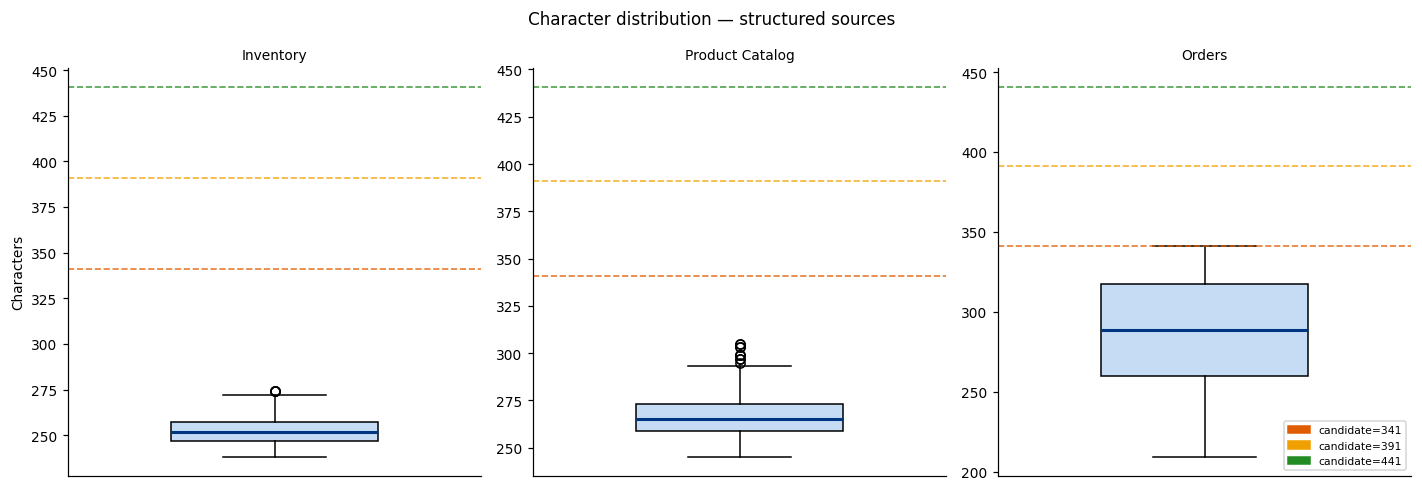

In [7]:
# --- Figure 1: boxplots for structured sources ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=False)

CANDIDATE_SIZES = [max_structured, max_structured + 50, max_structured + 100]
colors_cand = ["#e05c00", "#f0a000", "#228b22"]

for ax, name in zip(axes, structured):
    lengths = [len(d.page_content) for d in raw_docs[name]]
    ax.boxplot(
        lengths,
        widths=0.5,
        patch_artist=True,
        boxprops=dict(facecolor="#c6dcf5"),
        medianprops=dict(color="#003580", linewidth=2),
    )
    for size, col in zip(CANDIDATE_SIZES, colors_cand):
        ax.axhline(size, color=col, linestyle="--", linewidth=1.1, alpha=0.8)
    ax.set_title(name.replace("_", " ").title(), fontsize=9)
    ax.set_xticks([])
    ax.set_ylabel("Characters" if ax == axes[0] else "")

legend_handles = [
    mpatches.Patch(color=col, label=f"candidate={s}")
    for s, col in zip(CANDIDATE_SIZES, colors_cand)
]
axes[-1].legend(handles=legend_handles, fontsize=7, loc="lower right")

fig.suptitle("Character distribution — structured sources", fontsize=11)
plt.tight_layout()
plt.show()

In [8]:
# --- Figure 2: character lengths for PDF pages (the sources that WILL be split) ---
pdf_sources = ["returns_policy", "shipping_policy"]

for name in pdf_sources:
    print(f"\n=== {name} ===")
    for i, doc in enumerate(raw_docs[name]):
        text = doc.page_content
        print(
            f"  Page {doc.metadata.get('page', i+1)}: {len(text)} chars | {len(text.split())} words"
        )


=== returns_policy ===
  Page 1: 1907 chars | 294 words
  Page 2: 1420 chars | 213 words

=== shipping_policy ===
  Page 1: 1627 chars | 234 words


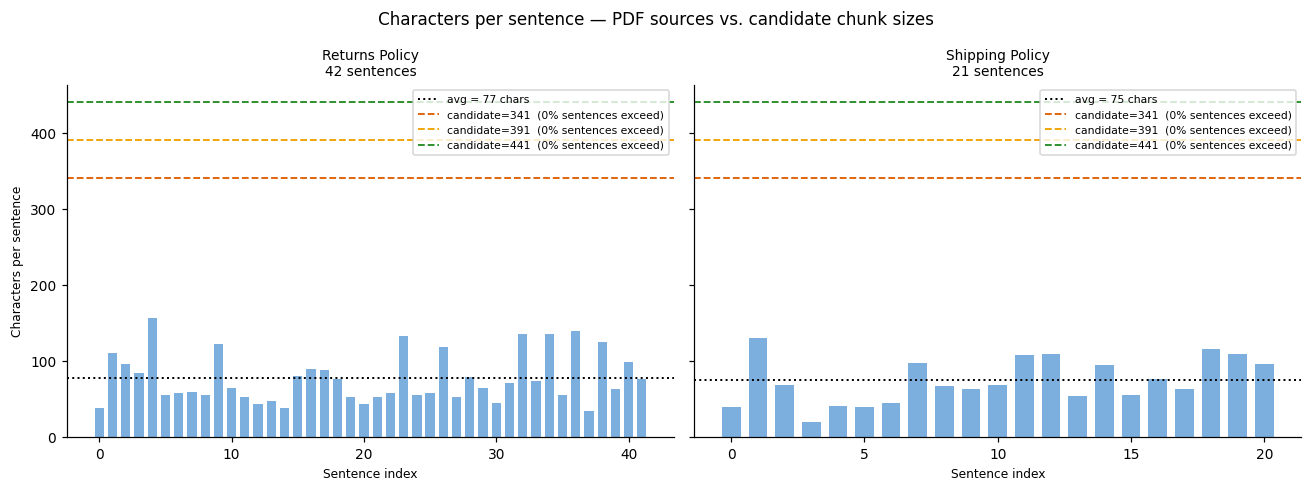

In [ ]:
# For the PDF sources, we want to understand the distribution of sentence lengths
# to assess how many sentences would be split at different candidate chunk sizes.


def _split_sentences(text: str) -> list[str]:
    """Split text into sentences on punctuation boundaries."""
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [s for s in parts if len(s.strip()) > 10]


# Collect sentence character lengths per PDF source
pdf_sources_list = ["returns_policy", "shipping_policy"]
pdf_sent_lengths: dict[str, list[int]] = {}
for name in pdf_sources_list:
    sentences = []
    for doc in raw_docs[name]:
        sentences.extend(_split_sentences(doc.page_content))
    pdf_sent_lengths[name] = [len(s) for s in sentences]

# --- Figure: chars per sentence vs. candidate chunk sizes ---
_colors_cand = ["#e05c00", "#f0a000", "#228b22"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, name in zip(axes, pdf_sources_list):
    lengths = pdf_sent_lengths[name]
    ax.bar(range(len(lengths)), lengths, color="#5b9bd5", alpha=0.8, width=0.7)

    avg_len = float(np.mean(lengths))
    ax.axhline(
        avg_len,
        color="black",
        linestyle=":",
        linewidth=1.3,
        label=f"avg = {avg_len:.0f} chars",
    )

    for size, col in zip(CANDIDATE_SIZES, _colors_cand):
        pct_exceed = 100 * sum(l > size for l in lengths) / len(lengths)
        ax.axhline(
            size,
            color=col,
            linestyle="--",
            linewidth=1.2,
            label=f"candidate={size}  ({pct_exceed:.0f}% sentences exceed)",
        )

    ax.set_title(
        f"{name.replace('_', ' ').title()}\n{len(lengths)} sentences", fontsize=9
    )
    ax.set_xlabel("Sentence index", fontsize=8)
    if ax == axes[0]:
        ax.set_ylabel("Characters per sentence", fontsize=8)
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle(
    "Characters per sentence — PDF sources vs. candidate chunk sizes", fontsize=11
)
plt.tight_layout()
plt.show()

---
## 4. Corpus Composition

In [11]:
total_docs = sum(len(d) for d in raw_docs.values())
total_chars = sum(len(doc.page_content) for docs in raw_docs.values() for doc in docs)

comp_rows = []
for name in SOURCES:
    docs = raw_docs[name]
    src_chars = sum(len(d.page_content) for d in docs)
    comp_rows.append(
        {
            "Source": name,
            "Docs": len(docs),
            "% docs": round(100 * len(docs) / total_docs, 1),
            "Chars": src_chars,
            "% chars": round(100 * src_chars / total_chars, 1),
        }
    )

comp_df = pd.DataFrame(comp_rows)
comp_df.style.bar(subset=["% docs", "% chars"], color="#c6dcf5").set_caption(
    "Corpus composition — document count vs. character share"
)

,Source,Docs,% docs,Chars,% chars
0,returns_policy,2,0.500000,3327,2.800000
1,shipping_policy,1,0.200000,1627,1.400000
2,inventory,200,46.200000,50497,43.000000
3,product_catalog,200,46.200000,53522,45.600000
4,orders,30,6.900000,8418,7.200000


---
## 5. Chunking Strategy — Candidate Evaluation

We test three candidate `chunk_size` values against two criteria:

1. **Structured integrity** — no orders, inventory, or catalog row should be split.
2. **PDF granularity** — each PDF page should produce 2–4 meaningful chunks (clause-level).

In [13]:
def evaluate_strategy(
    chunk_size: int,
    chunk_overlap: int,
    docs_by_source: dict,
) -> pd.DataFrame:
    """Apply a splitter to all sources and summarize split behaviour per source.

    Args:
        chunk_size: Maximum characters per chunk.
        chunk_overlap: Overlapping characters between consecutive chunks.
        docs_by_source: Mapping of source name to list of Documents.

    Returns:
        DataFrame with raw doc count, chunk count, ratio, and split flag per source.
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    rows = []
    for name, docs in docs_by_source.items():
        chunks = splitter.split_documents(docs)
        n_raw = len(docs)
        n_chunks = len(chunks)
        split = n_chunks > n_raw
        rows.append(
            {
                "Source": name,
                "Raw docs": n_raw,
                "Chunks": n_chunks,
                "Ratio": round(n_chunks / n_raw, 2) if n_raw else 0,
                "Split occurred": split,
            }
        )
    df = pd.DataFrame(rows)
    df.loc[len(df)] = ["TOTAL", df["Raw docs"].sum(), df["Chunks"].sum(), "", ""]
    return df

In [14]:
# Overlap values scaled proportionally to each candidate chunk_size (~12%)
CANDIDATES = [
    {
        "chunk_size": max_structured,
        "chunk_overlap": round(max_structured * 0.12 / 5) * 5,
    },
    {
        "chunk_size": max_structured + 50,
        "chunk_overlap": round((max_structured + 50) * 0.12 / 5) * 5,
    },
    {
        "chunk_size": max_structured + 100,
        "chunk_overlap": round((max_structured + 100) * 0.12 / 5) * 5,
    },
]

for c in CANDIDATES:
    print(f"chunk_size={c['chunk_size']:4d}  chunk_overlap={c['chunk_overlap']}")
    df = evaluate_strategy(c["chunk_size"], c["chunk_overlap"], raw_docs)
    structured_splits = df[df["Source"].isin(structured)]["Split occurred"].any()
    total_chunks = int(df.loc[df["Source"] == "TOTAL", "Chunks"].values[0])
    print(
        f"  Structured records split: {structured_splits} | Total chunks: {total_chunks}"
    )
    print()

chunk_size= 341  chunk_overlap=40
  Structured records split: False | Total chunks: 448

chunk_size= 391  chunk_overlap=45
  Structured records split: False | Total chunks: 445

chunk_size= 441  chunk_overlap=55
  Structured records split: False | Total chunks: 444



In [15]:
# Detailed table for each candidate
for c in CANDIDATES:
    print(f"\n{'='*60}")
    print(f"  chunk_size={c['chunk_size']}, chunk_overlap={c['chunk_overlap']}")
    print("=" * 60)
    df = evaluate_strategy(c["chunk_size"], c["chunk_overlap"], raw_docs)
    print(df.to_string(index=False))


  chunk_size=341, chunk_overlap=40
         Source  Raw docs  Chunks Ratio Split occurred
 returns_policy         2      12   6.0           True
shipping_policy         1       6   6.0           True
      inventory       200     200   1.0          False
product_catalog       200     200   1.0          False
         orders        30      30   1.0          False
          TOTAL       433     448                     

  chunk_size=391, chunk_overlap=45
         Source  Raw docs  Chunks Ratio Split occurred
 returns_policy         2      10   5.0           True
shipping_policy         1       5   5.0           True
      inventory       200     200   1.0          False
product_catalog       200     200   1.0          False
         orders        30      30   1.0          False
          TOTAL       433     445                     

  chunk_size=441, chunk_overlap=55
         Source  Raw docs  Chunks Ratio Split occurred
 returns_policy         2       9   4.5           True
shipping_pol

---
## 6. PDF Split Quality — Clause-Level Inspection

For each candidate, we inspect whether PDF splits fall on clause boundaries  
rather than mid-sentence. This is a qualitative check.

In [16]:
def inspect_pdf_chunks(chunk_size: int, chunk_overlap: int) -> None:
    """Print a preview of each chunk produced from the PDF policy sources.

    Args:
        chunk_size: Chunk size to use for splitting.
        chunk_overlap: Overlap between chunks.
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    pdf_docs = raw_docs["returns_policy"] + raw_docs["shipping_policy"]
    chunks = splitter.split_documents(pdf_docs)
    print(
        f"chunk_size={chunk_size}, chunk_overlap={chunk_overlap}  →  {len(chunks)} PDF chunks\n"
    )
    for i, chunk in enumerate(chunks):
        src = Path(chunk.metadata.get("source", "")).name
        page = chunk.metadata.get("page", "?")
        preview = chunk.page_content[:120].replace("\n", " ")
        tail = chunk.page_content[-50:].replace("\n", " ")
        print(f"  [{i+1:02d}] {src} p{page} | {len(chunk.page_content)} chars")
        print(f"       START: {preview}...")
        print(f"       END:   ...{tail}\n")


for c in CANDIDATES:
    print("=" * 70)
    inspect_pdf_chunks(c["chunk_size"], c["chunk_overlap"])

chunk_size=341, chunk_overlap=40  →  18 PDF chunks

  [01] EcoMarket ReturnPolicy.pdf p1 | 333 chars
       START: EcoMarket Return & Refund Policy    1. Scope and Purpose  This Return & Refund Policy governs all purchases made through...
       END:   ...nowledge and agree to the terms described  herein.

  [02] EcoMarket ReturnPolicy.pdf p1 | 280 chars
       START: herein.  2. Eligibility for Returns  Products are eligible for return within 30 calendar days from the date of delivery,...
       END:   ...inal packaging, labels, and accessories are intact

  [03] EcoMarket ReturnPolicy.pdf p1 | 304 chars
       START: c. Proof of purchase (order number or receipt) is provided  d. The product is not listed under non-returnable items  3. ...
       END:   ...goods (e.g., fresh produce, dairy, prepared foods)

  [04] EcoMarket ReturnPolicy.pdf p1 | 309 chars
       START: b. Opened or used hygiene and personal care products  c. Items marked as final sale or clearance  d. Gift cards and d

---
## 7. Proposed Chunking Strategy

Based on the measurements above, we select the `chunk_size` that satisfies both criteria.

### Recommended chunking parameters

| Parameter | Value | Derivation |
|---|---|---|
| `chunk_size` | **391 chars** | `max_structured` (341) + safety margin (50) |
| `chunk_overlap` | **45 chars** | 12% of `chunk_size`, rounded to nearest 5 |

**Derivation:**
- Max structured doc length: **341 chars** (orders)
- Safety margin: **+50 chars**
- Overlap ratio: **12%** of chunk_size — enough to bridge clause boundaries
- Estimated token count: **~98 tokens** (limit: 256)

In [26]:
RECOMMENDED_CHUNK_SIZE = 391
RECOMMENDED_CHUNK_OVERLAP = 45

# Validate recommended parameters
final_df = evaluate_strategy(
    RECOMMENDED_CHUNK_SIZE, RECOMMENDED_CHUNK_OVERLAP, raw_docs
)

structured_splits = final_df[final_df["Source"].isin(structured)][
    "Split occurred"
].any()

pdf_chunks = int(
    final_df[final_df["Source"].isin(["returns_policy", "shipping_policy"])][
        "Chunks"
    ].sum()
)

total_chunks = int(final_df.loc[final_df["Source"] == "TOTAL", "Chunks"].values[0])

print(
    f"Validation — chunk_size={RECOMMENDED_CHUNK_SIZE}, chunk_overlap={RECOMMENDED_CHUNK_OVERLAP}"
)
print(f"  Structured records split: {structured_splits}  (expected: False)")
print(f"  PDF chunks produced:      {pdf_chunks}")
print(f"  Total chunks:             {total_chunks}")
print()
print(final_df.to_string(index=False))

Validation — chunk_size=391, chunk_overlap=45
  Structured records split: False  (expected: False)
  PDF chunks produced:      15
  Total chunks:             445

         Source  Raw docs  Chunks Ratio Split occurred
 returns_policy         2      10   5.0           True
shipping_policy         1       5   5.0           True
      inventory       200     200   1.0          False
product_catalog       200     200   1.0          False
         orders        30      30   1.0          False
          TOTAL       433     445                     


---
## 8. Summary

The table below consolidates the measurements and the resulting chunking decisions.

In [21]:
summary_rows = [
    {
        "Source": "returns_policy",
        "Type": "PDF",
        "Max chars": max(len(d.page_content) for d in raw_docs["returns_policy"]),
        "Above limit": "Yes",
        "Expected behaviour": "Split into 2–4 chunks per page (clause-level granularity)",
    },
    {
        "Source": "shipping_policy",
        "Type": "PDF",
        "Max chars": max(len(d.page_content) for d in raw_docs["shipping_policy"]),
        "Above limit": "Yes",
        "Expected behaviour": "Split into 2–3 chunks (clause-level granularity)",
    },
    {
        "Source": "inventory",
        "Type": "Excel",
        "Max chars": max(len(d.page_content) for d in raw_docs["inventory"]),
        "Above limit": "No",
        "Expected behaviour": "Never split — each row is one atomic chunk",
    },
    {
        "Source": "product_catalog",
        "Type": "Excel",
        "Max chars": max(len(d.page_content) for d in raw_docs["product_catalog"]),
        "Above limit": "No",
        "Expected behaviour": "Never split — each row is one atomic chunk",
    },
    {
        "Source": "orders",
        "Type": "JSON",
        "Max chars": max(len(d.page_content) for d in raw_docs["orders"]),
        "Above limit": "No",
        "Expected behaviour": "Never split — each order is one atomic chunk",
    },
]

summary_df = pd.DataFrame(summary_rows)
summary_df.style.apply(
    lambda col: [
        "background: #ffe0b2" if v == "Yes" else "background: #d4edda" for v in col
    ],
    subset=["Above limit"],
).set_caption(
    f"Chunking strategy summary — chunk_size={RECOMMENDED_CHUNK_SIZE}, "
    f"chunk_overlap={RECOMMENDED_CHUNK_OVERLAP}"
)

,Source,Type,Max chars,Above limit,Expected behaviour
0,returns_policy,PDF,1907,Yes,Split into 2–4 chunks per page (clause-level granularity)
1,shipping_policy,PDF,1627,Yes,Split into 2–3 chunks (clause-level granularity)
2,inventory,Excel,274,No,Never split — each row is one atomic chunk
3,product_catalog,Excel,305,No,Never split — each row is one atomic chunk
4,orders,JSON,341,No,Never split — each order is one atomic chunk


---
## Final Recommended Chunking Parameters

> Values derived programmatically from the measured corpus. See Section 8 for the supporting analysis.

| Parameter | Recommended Value | Derivation |
|---|---:|---|
| Chunk size | **391 characters** | Based on the largest structured record plus margin |
| Chunk overlap | **45 characters** | Preserves context across clause boundaries |


### Rationale

| Criterion | Result |
|---|---|
| Largest structured document type | Orders |
| Maximum structured document length | 341 characters |
| Structured records split | **0** — inventory, catalog, and order records remain intact |
| PDF page length range | 1,420–1,907 characters |
| PDF splitting behavior | Approximately 5 chunks per page |
| Estimated chunk size in tokens | ~98 tokens, within the 256-token limit |
| Overlap coverage | ~11 words carried across chunk boundaries |
| **Total corpus chunks** | **445** |